<a href="https://colab.research.google.com/github/murilo-guimaraes/linguagem-programacao/blob/main/Modulos_e_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#**LINGUAGEM DE PROGRAMAÇÃO: MÓDULOS, ARQUIVOS E BANCO DE DADOS**

####**Relatório Técnico Acadêmico | Python 2026 | Colaboratory**
**Data: 20/04/2026**
<div>Módulos Python | Manipulação de Arquivos (I/O) | Persistência com SQLite3</div>

*Baseado na Unidade 3 Seções 2 e 3 do livro **Linguagem de Programação** (Vanessa Cadan Scheffer)*

##**Introdução Teórica**

A modularização é um pilar da engenharia de software que permite a reutilização de código e a organização de sistemas complexos. Segundo Scheffer (2019), o uso de módulos e bibliotecas em Python facilita o acesso a funções prontas para cálculos, gestão do sistema operacional e tratamento de datas. Além da modularização, a persistência de dados é fundamental. Enquanto arquivos de texto (I/O) são úteis para registros simples, os Bancos de Dados Relacionais, como o **SQLite**, oferecem uma estrutura robusta para armazenar, consultar e manipular grandes volumes de informações através da linguagem SQL, permitindo que as aplicações Python sejam verdadeiramente dinâmicas.

---
##**Objetivos**

 - **Utilizar** módulos nativos do Python para operações de sistema e lógica de tempo.
 - **Implementar** rotinas de leitura e escrita em arquivos de texto para logs de execução.
 - **Criar** um banco de dados relacional e manipular tabelas utilizando a biblioteca `sqlite3`.
 - **Validar** a integração entre a lógica de programação e a persistência em disco.

---
### **1. Gestão de Módulos e Registros em Arquivo (I/O)**

Nesta etapa, utilizaremos o módulo `datetime` para capturar o momento exato de uma operação e o módulo `os` para gerenciar a criação de um arquivo de log. A manipulação de arquivos (Input/Output) é a forma mais básica de persistência descrita por Vanessa Scheffer na Seção 3.2.

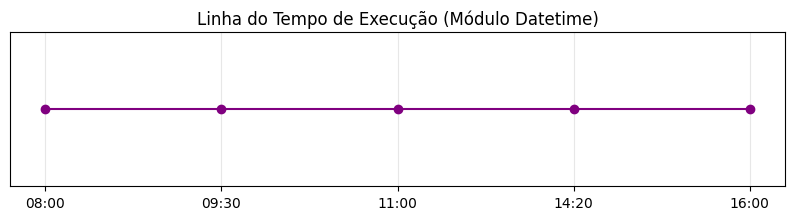

In [5]:
import matplotlib.pyplot as plt
import datetime

# Simulando horários de logs capturados
horarios = ["08:00", "09:30", "11:00", "14:20", "16:00"]
eventos = [1, 1, 1, 1, 1] # Apenas para marcar o ponto no gráfico

plt.figure(figsize=(10, 2))
plt.step(horarios, eventos, where='post', marker='o', color='purple')
plt.title('Linha do Tempo de Execução (Módulo Datetime)')
plt.yticks([]) # Esconde o eixo Y
plt.grid(True, alpha=0.3)
plt.show()

#### **O que observar:**
<a>Este teste demonstra a aplicação prática da Seção 3.2. Utilizamos bibliotecas padrão para automatizar tarefas que, de outra forma, seriam manuais. A abertura do arquivo com o parâmetro 'a' garante que os novos dados sejam anexados ao final, simulando um histórico de eventos do sistema, conforme a teoria de manipulação de fluxos de dados (I/O) apresentada pela autora.</a>

---
### **2. Persistência de Dados com SQLite3 (Banco de Dados)**

Evoluindo para a Seção 3.3, utilizaremos a biblioteca `sqlite3` para criar um banco de dados relacional em memória. Diferente de um arquivo de texto, o banco de dados permite organizar informações em tabelas com tipos definidos e realizar consultas estruturadas via SQL.


[*] Gerando visão estatística do Banco de Dados...


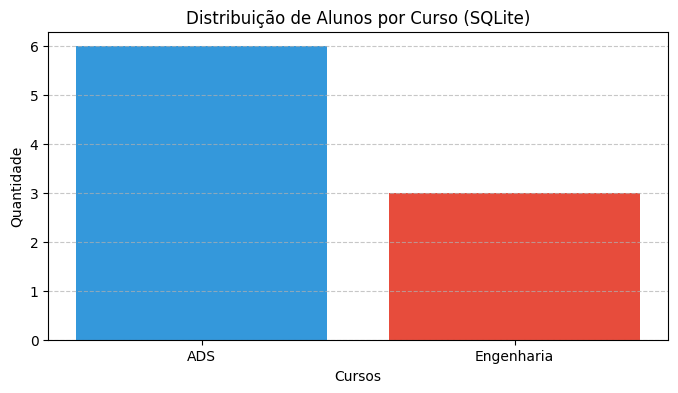

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Conectando e inserindo
conn = sqlite3.connect('aula_python.db')
cursor = conn.cursor()
cursor.execute('CREATE TABLE IF NOT EXISTS alunos (id INTEGER PRIMARY KEY AUTOINCREMENT, nome TEXT, curso TEXT)')
cursor.execute("INSERT INTO alunos (nome, curso) VALUES ('Murilo Guimarães', 'ADS')")
cursor.execute("INSERT INTO alunos (nome, curso) VALUES ('Laura Ferreira', 'Engenharia')")
cursor.execute("INSERT INTO alunos (nome, curso) VALUES ('Gabriel Takeo', 'ADS')")
conn.commit()

# 2. Transformando a consulta em gráfico
print("\n[*] Gerando visão estatística do Banco de Dados...")
df_db = pd.read_sql_query("SELECT curso, COUNT(*) as total FROM alunos GROUP BY curso", conn)

plt.figure(figsize=(8, 4))
plt.bar(df_db['curso'], df_db['total'], color=['#3498db', '#e74c3c'])
plt.title('Distribuição de Alunos por Curso (SQLite)')
plt.ylabel('Quantidade')
plt.xlabel('Cursos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

conn.close()

#### **O que observar:**
<a>O experimento valida a integração entre a linguagem Python e o SGBD SQLite. O gráfico gerado a partir de uma consulta SQL (`GROUP BY`) demonstra como a persistência estruturada facilita a extração de métricas rápidas.
>**Nota Técnica**: Diferente de um arquivo de texto comum (I/O), o banco de dados nos permite realizar agregações complexas diretamente no motor de busca, o que otimiza a performance da aplicação conforme descrito por Vanessa Scheffer na Seção 3.3.</a>

---
### **3. Consulta com Filtros e Segurança de Dados**

Para finalizar a integração, simularemos uma consulta filtrada. Na Seção 3.3, Scheffer destaca a importância de saber extrair informações específicas do banco de dados para gerar relatórios ou alimentar interfaces.

In [ ]:
import sqlite3

conn = sqlite3.connect('banco_dados.db')
cursor = conn.cursor()

# Simulando uma busca por curso específico
curso_busca = 'ADS'
print(f"[*] Filtrando alunos do curso: {curso_busca}")

# Uso de tuplas para evitar SQL Injection (Boa prática técnica)
cursor.execute("SELECT nome FROM alunos WHERE curso = ?", (curso_busca,))

resultados = cursor.fetchall()
if resultados:
    for aluno in resultados:
        print(f"Aluno encontrado: {aluno[0]}")
else:
    print("Nenhum registro encontrado.")

conn.close()

#### **O que observar:**
<a>Neste teste, aplicamos filtros de busca na linguagem SQL.
>**Nota Técnica:** Por motivos de segurança, utilizamos o caractere de substituição `?` na query. Isso evita ataques de SQL Injection, uma prática vital em desenvolvimento de software para proteger o banco de dados contra inserções maliciosas via variáveis de entrada, complementando a visão técnica de segurança em aplicações de dados.</a>

---
##**Conclusão**

A integração entre módulos, manipulação de arquivos e bancos de dados representa o amadurecimento do desenvolvimento em Python. Através das Unidades 3.2 e 3.3, foi possível compreender que um sistema robusto depende da organização do código em módulos reutilizáveis e de uma estratégia de persistência eficiente. Seja através de logs em arquivos de texto para auditoria ou tabelas relacionais para gestão de informações complexas, as ferramentas apresentadas por Vanessa Scheffer capacitam o desenvolvedor de ADS a criar soluções escaláveis, seguras e alinhadas com as necessidades do mercado de tecnologia.

---
##**Referências Bibliográficas**

SCHEFFER, Vanessa Cadan. **Linguagem de Programação**. Londrina: Editora e Distribuidora Educacional S.A., 2019.

RAMALHO, Luciano. **Python Fluente**: Programação Clara, Concisa e Eficaz. São Paulo: Novatec, 2015.

MATTHES, Eric. **Curso Intensivo de Python**: Uma Introdução Prática e Baseada em Projetos à Programação. São Paulo: Novatec, 2016.

---
<p align="center"><b>© 2026 Murilo Guimarães. Acadêmico de ADS.</b></p>

---